In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from scipy.stats import spearmanr
from tqdm.auto import tqdm

# ==========================================
# 1. SETUP & DATA PREPROCESSING
# ==========================================
# Split costs so the AI knows the difference between booting a tool and calculating a score
base_costs = {"diffdock": 407.5, "flexx": 3.33, "smina": 99.9, "plants": 6.85, "gnina": 105.8}
score_costs = {
    'cnnscore': 0.31, 'cnnaffinity': 0.31, 'smina_affinity': 0.31, 'rtmscore': 0.41,
    'scorch': 4.63, 'hyde': 2.0, 'chemplp': 0.121, 'rfscore_v2': 0.687,
    'vina_hydrophobic': 0.69, 'vina_intra_hydrophobic': 0.69
}

print("Loading and Aggregating Data...")
df_orig = pd.read_csv("all_rescoring_results_merged.csv")

# Standardize tool names early
df_orig['docking_tool'] = df_orig['docking_tool'].str.lower()
df_orig['docking_tool'] = df_orig['docking_tool'].replace('localdiffdock', 'diffdock')

agg_rules = {
    'CNNscore': 'max', 'CNNaffinity': 'max', 'smina_affinity': 'max',
    'RTMScore': 'max', 'SCORCH': 'max', 'HYDE': 'max', 'rfscore_v2': 'max',
    'CHEMPLP': 'min', 'vina_hydrophobic': 'min', 'vina_intra_hydrophobic': 'min',
    'true_value': 'first', 'activity_class': 'first'
}

for col in df_orig.select_dtypes(include=np.number).columns:
    if col not in agg_rules and col not in ["pose", "id", "true_value", "activity_class"]:
        agg_rules[col] = "mean"

df_agg = df_orig.groupby(["id","docking_tool"]).agg(agg_rules).reset_index()

meta_cols = ["true_value", "activity_class"]
score_cols = [c for c in df_agg.columns if c not in meta_cols and c not in ["id","docking_tool"]]

# Pivot to wide format
wide = df_agg.set_index(["id", "docking_tool"])[score_cols].unstack("docking_tool")
wide.columns = [f"{tool}_{score}" for score, tool in wide.columns]
meta = df_agg.groupby("id")[meta_cols].first()
df_matrix = wide.join(meta)

# XGBoost can handle NaNs natively, but linear models/baseline comparisons often require numering them.
# We will leave NaNs as they are to let XGBoost use its sparsity-aware splits!
X_full = df_matrix.drop(columns=["true_value", "activity_class"])
y_full = df_matrix["true_value"]

X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

all_docking_tools = list(base_costs.keys())
all_score_names = list(score_costs.keys())

# ==========================================
# 2. THE ALPHA-PENALTY EVALUATOR
# ==========================================
def run_single_alpha(alpha, run_id, X_tr, X_te, y_tr, y_te):
    active_features = list(X_tr.columns)
    model = XGBRegressor(max_depth=4, learning_rate=0.05, n_estimators=150, random_state=run_id, n_jobs=-1)
    
    # We will log the entire elimination journey for deep analysis
    elimination_log = []
    step = 0
    
    while len(active_features) > 0:
        # 1. Train the current model
        model.fit(X_tr[active_features], y_tr)
        
        # Map importances to feature names
        importances = dict(zip(active_features, model.feature_importances_))
        
        # 2. Calculate the "Net Value of Keeping" for EVERY possible action
        net_values = {}
        
        # ACTION A: Evaluate keeping each Individual Feature
        for feat in active_features:
            tool, score = feat.split('_', 1)
            tool, score = tool.lower(), score.lower()
            
            feat_cost = score_costs.get(score, 0)
            # If it is the last feature for this tool, keeping it costs the Base Cost too
            tool_feats = [f for f in active_features if f.startswith(tool)]
            if len(tool_feats) == 1:
                feat_cost += base_costs.get(tool, 0)
                
            net_values[feat] = importances[feat] - (alpha * feat_cost)
            
        # ACTION B: Evaluate keeping each Whole Tool
        active_tools = set([f.split('_')[0].lower() for f in active_features])
        for tool in active_tools:
            tool_feats = [f for f in active_features if f.startswith(tool)]
            # Only evaluate as a group if there's actually more than 1 feature left
            if len(tool_feats) > 1:
                tool_importance = sum([importances[f] for f in tool_feats])
                tool_cost = base_costs.get(tool, 0) + sum([score_costs.get(f.split('_', 1)[1].lower(), 0) for f in tool_feats])
                
                net_values[f"ENTIRE_TOOL_{tool}"] = tool_importance - (alpha * tool_cost)
                
        # 3. Find the Absolute Worst Item (Global Minimum Net Value)
        worst_item = min(net_values, key=net_values.get)
        worst_val = net_values[worst_item]
        
        # 4. CALCULATE & LOG CURRENT METRICS (Before Dropping!)
        pred_train = model.predict(X_tr[active_features])
        pred_test = model.predict(X_te[active_features])
        
        current_pipeline_cost = sum([base_costs.get(t, 0) for t in active_tools]) + \
                                sum([score_costs.get(f.split('_', 1)[1].lower(), 0) for f in active_features])
                                
        elimination_log.append({
            "alpha": alpha,
            "run": run_id,
            "step": step,
            "active_features_count": len(active_features),
            "pipeline_cost": current_pipeline_cost,
            "mse_train": mean_squared_error(y_tr, pred_train),
            "mse_test": mean_squared_error(y_te, pred_test),
            "spearman_test": spearmanr(pred_test, y_te)[0],
            "dropped_item": worst_item if worst_val < 0 else "NONE - OPTIMAL",
            "dropped_net_value": worst_val
        })
        
        # 5. STOPPING CONDITION: If the worst item is still positive, the model is optimal for this budget!
        if worst_val >= 0:
            break
            
        # 6. EXECUTE THE DROP
        if worst_item.startswith("ENTIRE_TOOL_"):
            tool_to_drop = worst_item.replace("ENTIRE_TOOL_", "")
            active_features = [f for f in active_features if not f.startswith(tool_to_drop)]
        else:
            active_features.remove(worst_item)
            
        step += 1
        
    # --- RETURN DATA ---
    # We return the FINAL state of this alpha 
    # AND we return the elimination_log (so you can analyze the exact death of every feature)
    
    final_row = elimination_log[-1].copy() # The last log entry is the optimal stable state
    
    # Add the binary 1/0 flags for the final state
    for tool in all_docking_tools:
        final_row[f"sel_{tool}"] = 1 if any(f.startswith(tool) for f in active_features) else 0
    for score in all_score_names:
        final_row[f"sel_{score}"] = 1 if any(f.endswith(score) for f in active_features) else 0
        
    return final_row, elimination_log

# ==========================================
# 3. MASS PARALLEL GRID SEARCH
# ==========================================
print("Running Alpha Parameter Sweep...")

# We use a slightly different logspace because XGBoost feature importances sum to 1.0
alphas = [0] + list(np.logspace(-5, -1, 20))
n_runs = 5 # 5 runs per alpha is enough for XGBoost to show variance via different random seeds

rows = []
for alpha in tqdm(alphas, desc="Evaluating Alphas"):
    for run in range(n_runs):
        row = run_single_alpha(alpha, run, X_train, X_test, y_train, y_test)
        rows.append(row)

# The final dataframe, ready for plotting in the next chat!
df_weights = pd.DataFrame(rows)
print("\nSweep Complete! Generated {} models.".format(len(df_weights)))
print("Preview of generated rows:")


In [8]:
pd.set_option('display.max_colwidth', None)
display(df_weights)

,0,1
0,"{'alpha': 0, 'run': 0, 'step': 0, 'active_features_count': 50, 'pipeline_cost': 674.17, 'mse_train': 0.018934438608373797, 'mse_test': 1.910502465190371, 'spearman_test': 0.25175312537491473, 'dropped_item': 'NONE - OPTIMAL', 'dropped_net_value': 0.003078944, 'sel_diffdock': 1, 'sel_flexx': 1, 'sel_smina': 1, 'sel_plants': 1, 'sel_gnina': 1, 'sel_cnnscore': 0, 'sel_cnnaffinity': 0, 'sel_smina_affinity': 1, 'sel_rtmscore': 0, 'sel_scorch': 0, 'sel_hyde': 0, 'sel_chemplp': 0, 'sel_rfscore_v2': 1, 'sel_vina_hydrophobic': 1, 'sel_vina_intra_hydrophobic': 1}","[{'alpha': 0, 'run': 0, 'step': 0, 'active_features_count': 50, 'pipeline_cost': 674.17, 'mse_train': 0.018934438608373797, 'mse_test': 1.910502465190371, 'spearman_test': 0.25175312537491473, 'dropped_item': 'NONE - OPTIMAL', 'dropped_net_value': 0.003078944}]"
1,"{'alpha': 0, 'run': 1, 'step': 0, 'active_features_count': 50, 'pipeline_cost': 674.17, 'mse_train': 0.018934438608373797, 'mse_test': 1.910502465190371, 'spearman_test': 0.25175312537491473, 'dropped_item': 'NONE - OPTIMAL', 'dropped_net_value': 0.003078944, 'sel_diffdock': 1, 'sel_flexx': 1, 'sel_smina': 1, 'sel_plants': 1, 'sel_gnina': 1, 'sel_cnnscore': 0, 'sel_cnnaffinity': 0, 'sel_smina_affinity': 1, 'sel_rtmscore': 0, 'sel_scorch': 0, 'sel_hyde': 0, 'sel_chemplp': 0, 'sel_rfscore_v2': 1, 'sel_vina_hydrophobic': 1, 'sel_vina_intra_hydrophobic': 1}","[{'alpha': 0, 'run': 1, 'step': 0, 'active_features_count': 50, 'pipeline_cost': 674.17, 'mse_train': 0.018934438608373797, 'mse_test': 1.910502465190371, 'spearman_test': 0.25175312537491473, 'dropped_item': 'NONE - OPTIMAL', 'dropped_net_value': 0.003078944}]"
2,"{'alpha': 0, 'run': 2, 'step': 0, 'active_features_count': 50, 'pipeline_cost': 674.17, 'mse_train': 0.018934438608373797, 'mse_test': 1.910502465190371, 'spearman_test': 0.25175312537491473, 'dropped_item': 'NONE - OPTIMAL', 'dropped_net_value': 0.003078944, 'sel_diffdock': 1, 'sel_flexx': 1, 'sel_smina': 1, 'sel_plants': 1, 'sel_gnina': 1, 'sel_cnnscore': 0, 'sel_cnnaffinity': 0, 'sel_smina_affinity': 1, 'sel_rtmscore': 0, 'sel_scorch': 0, 'sel_hyde': 0, 'sel_chemplp': 0, 'sel_rfscore_v2': 1, 'sel_vina_hydrophobic': 1, 'sel_vina_intra_hydrophobic': 1}","[{'alpha': 0, 'run': 2, 'step': 0, 'active_features_count': 50, 'pipeline_cost': 674.17, 'mse_train': 0.018934438608373797, 'mse_test': 1.910502465190371, 'spearman_test': 0.25175312537491473, 'dropped_item': 'NONE - OPTIMAL', 'dropped_net_value': 0.003078944}]"
3,"{'alpha': 0, 'run': 3, 'step': 0, 'active_features_count': 50, 'pipeline_cost': 674.17, 'mse_train': 0.018934438608373797, 'mse_test': 1.910502465190371, 'spearman_test': 0.25175312537491473, 'dropped_item': 'NONE - OPTIMAL', 'dropped_net_value': 0.003078944, 'sel_diffdock': 1, 'sel_flexx': 1, 'sel_smina': 1, 'sel_plants': 1, 'sel_gnina': 1, 'sel_cnnscore': 0, 'sel_cnnaffinity': 0, 'sel_smina_affinity': 1, 'sel_rtmscore': 0, 'sel_scorch': 0, 'sel_hyde': 0, 'sel_chemplp': 0, 'sel_rfscore_v2': 1, 'sel_vina_hydrophobic': 1, 'sel_vina_intra_hydrophobic': 1}","[{'alpha': 0, 'run': 3, 'step': 0, 'active_features_count': 50, 'pipeline_cost': 674.17, 'mse_train': 0.018934438608373797, 'mse_test': 1.910502465190371, 'spearman_test': 0.25175312537491473, 'dropped_item': 'NONE - OPTIMAL', 'dropped_net_value': 0.003078944}]"
4,"{'alpha': 0, 'run': 4, 'step': 0, 'active_features_count': 50, 'pipeline_cost': 674.17, 'mse_train': 0.018934438608373797, 'mse_test': 1.910502465190371, 'spearman_test': 0.25175312537491473, 'dropped_item': 'NONE - OPTIMAL', 'dropped_net_value': 0.003078944, 'sel_diffdock': 1, 'sel_flexx': 1, 'sel_smina': 1, 'sel_plants': 1, 'sel_gnina': 1, 'sel_cnnscore': 0, 'sel_cnnaffinity': 0, 'sel_smina_affinity': 1, 'sel_rtmscore': 0, 'sel_scorch': 0, 'sel_hyde': 0, 'sel_chemplp': 0, 'sel_rfscore_v2': 1, 'sel_vina_hydrophobic': 1, 'sel_vina_intra_hydrophobic': 1}","[{'alpha': 0, 'run': 4, 'step': 0, 'active_features_count': 50, 'pipeline_cost': 674.17, 'mse_train': 0.01893443860837

In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from scipy.stats import spearmanr
from tqdm.auto import tqdm

# ==========================================
# 1. SETUP & DATA PREPROCESSING
# ==========================================
# Split costs so the AI knows the difference between booting a tool and calculating a score
base_costs = {"diffdock": 407.5, "flexx": 3.33, "smina": 99.9, "plants": 6.85, "gnina": 105.8}
score_costs = {
    'cnnscore': 0.31, 'cnnaffinity': 0.31, 'smina_affinity': 0.31, 'rtmscore': 0.41,
    'scorch': 4.63, 'hyde': 2.0, 'chemplp': 0.121, 'rfscore_v2': 0.687,
    'vina_hydrophobic': 0.69, 'vina_intra_hydrophobic': 0.69
}
MAX_COST = 407.50
norm_base_costs = {k: v / MAX_COST for k, v in base_costs.items()}
norm_score_costs = {k: v / MAX_COST for k, v in score_costs.items()}
print("Loading and Aggregating Data...")
df_orig = pd.read_csv("all_rescoring_results_merged.csv")

# Standardize tool names early
df_orig['docking_tool'] = df_orig['docking_tool'].str.lower()
df_orig['docking_tool'] = df_orig['docking_tool'].replace('localdiffdock', 'diffdock')

agg_rules = {
    'CNNscore': 'max', 'CNNaffinity': 'max', 'smina_affinity': 'max',
    'RTMScore': 'max', 'SCORCH': 'max', 'HYDE': 'max', 'rfscore_v2': 'max',
    'CHEMPLP': 'min', 'vina_hydrophobic': 'min', 'vina_intra_hydrophobic': 'min',
    'true_value': 'first', 'activity_class': 'first'
}

for col in df_orig.select_dtypes(include=np.number).columns:
    if col not in agg_rules and col not in ["pose", "id", "true_value", "activity_class"]:
        agg_rules[col] = "mean"

df_agg = df_orig.groupby(["id","docking_tool"]).agg(agg_rules).reset_index()

meta_cols = ["true_value", "activity_class"]
score_cols = [c for c in df_agg.columns if c not in meta_cols and c not in ["id","docking_tool"]]

# Pivot to wide format
wide = df_agg.set_index(["id", "docking_tool"])[score_cols].unstack("docking_tool")
wide.columns = [f"{tool}_{score}" for score, tool in wide.columns]
meta = df_agg.groupby("id")[meta_cols].first()
df_matrix = wide.join(meta)

# XGBoost can handle NaNs natively, but linear models/baseline comparisons often require numering them.
# We will leave NaNs as they are to let XGBoost use its sparsity-aware splits!
X_full = df_matrix.drop(columns=["true_value", "activity_class"])
y_full = df_matrix["true_value"]

X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

all_docking_tools = list(base_costs.keys())
all_score_names = list(score_costs.keys())

# ==========================================
# 2. THE ALPHA-PENALTY EVALUATOR
# ==========================================
def run_single_alpha(alpha, run_id, X_tr, X_te, y_tr, y_te):
    active_features = list(X_tr.columns)
    model = XGBRegressor(max_depth=4, learning_rate=0.05, n_estimators=150, random_state=run_id, n_jobs=-1)
    
    # We will log the entire elimination journey for deep analysis
    elimination_log = []
    step = 0
    
    while len(active_features) > 0:
        # 1. Train the current model
        model.fit(X_tr[active_features], y_tr)
        
        # Map importances to feature names
        importances = dict(zip(active_features, model.feature_importances_))
        
        # 2. Calculate the "Net Value of Keeping" for EVERY possible action
        net_values = {}
        
        # ACTION A: Evaluate keeping each Individual Feature
        for feat in active_features:
            tool, score = feat.split('_', 1)
            tool, score = tool.lower(), score.lower()
            
            feat_norm_cost = norm_score_costs.get(score, 0)
            # If it is the last feature for this tool, keeping it costs the Base Cost too
            tool_feats = [f for f in active_features if f.startswith(tool)]
            if len(tool_feats) == 1:
                feat_norm_cost += norm_base_costs.get(tool, 0)
                
            net_values[feat] = importances[feat] - (alpha * feat_norm_cost)
            
        # ACTION B: Evaluate keeping each Whole Tool
        active_tools = set([f.split('_')[0].lower() for f in active_features])
        for tool in active_tools:
            tool_feats = [f for f in active_features if f.startswith(tool)]
            # Only evaluate as a group if there's actually more than 1 feature left
            if len(tool_feats) > 1:
                tool_importance = sum([importances[f] for f in tool_feats])
                tool_norm_cost = norm_base_costs.get(tool, 0) + sum([norm_score_costs.get(f.split('_', 1)[1].lower(), 0) for f in tool_feats])
                
                net_values[f"ENTIRE_TOOL_{tool}"] = tool_importance - (alpha * tool_norm_cost)
        # 3. Find the Absolute Worst Item (Global Minimum Net Value)
        worst_item = min(net_values, key=net_values.get)
        worst_val = net_values[worst_item]
        
        # 4. CALCULATE & LOG CURRENT METRICS (Before Dropping!)
        pred_train = model.predict(X_tr[active_features])
        pred_test = model.predict(X_te[active_features])
        
        current_pipeline_cost = sum([base_costs.get(t, 0) for t in active_tools]) + \
                                sum([score_costs.get(f.split('_', 1)[1].lower(), 0) for f in active_features])
                                
        elimination_log.append({
            "alpha": alpha,
            "run": run_id,
            "step": step,
            "active_features_count": len(active_features),
            "pipeline_cost": current_pipeline_cost,
            "mse_train": mean_squared_error(y_tr, pred_train),
            "mse_test": mean_squared_error(y_te, pred_test),
            "spearman_test": spearmanr(pred_test, y_te)[0],
            "dropped_item": worst_item if worst_val < 0 else "NONE - OPTIMAL",
            "dropped_net_value": worst_val
        })
        
        # 5. STOPPING CONDITION: If the worst item is still positive, the model is optimal for this budget!
        if worst_val >= 0:
            break
            
        # 6. EXECUTE THE DROP
        if worst_item.startswith("ENTIRE_TOOL_"):
            tool_to_drop = worst_item.replace("ENTIRE_TOOL_", "")
            active_features = [f for f in active_features if not f.startswith(tool_to_drop)]
        else:
            active_features.remove(worst_item)
            
        step += 1
        
    # --- RETURN DATA ---
    # We return the FINAL state of this alpha
    # AND we return the elimination_log (so you can analyze the exact death of every feature)
    
    final_row = elimination_log[-1].copy() # The last log entry is the optimal stable state
    
    # Add the binary 1/0 flags for the final state
    for tool in all_docking_tools:
        final_row[f"sel_{tool}"] = 1 if any(f.startswith(tool) for f in active_features) else 0
    for score in all_score_names:
        final_row[f"sel_{score}"] = 1 if any(f.endswith(score) for f in active_features) else 0
        
    return final_row, elimination_log

# ==========================================
# 3. MASS PARALLEL GRID SEARCH
# ==========================================
print("Running Alpha Parameter Sweep...")

# We use np.linspace to map alpha intuitively from 0.0 to 1.0
# alphas = np.linspace(0.0, 1.0, 21)
alphas = np.linspace(0.0, 50.0, 21)
n_runs = 5 # 5 runs per alpha is enough for XGBoost to show variance via different random seeds

final_models = []
all_logs = []

for alpha in tqdm(alphas, desc="Evaluating Alphas"):
    for run in range(n_runs):
        # UNPACKING THE TUPLE: this fixes the Column 0 / Column 1 issue
        final_row, history_log = run_single_alpha(alpha, run, X_train, X_test, y_train, y_test)
        final_models.append(final_row)
        all_logs.append(history_log)

# The final dataframe, ready for plotting!
df_weights = pd.DataFrame(final_models)
print("\nSweep Complete! Generated {} models.".format(len(df_weights)))
# display(df_weights.head(10))

Loading and Aggregating Data...
Running Alpha Parameter Sweep...


Evaluating Alphas:   0%|          | 0/21 [00:00<?, ?it/s]


Sweep Complete! Generated 105 models.


In [13]:
pd.set_option('display.max_colwidth', None)
display(df_weights)

,alpha,run,step,active_features_count,pipeline_cost,mse_train,mse_test,spearman_test,dropped_item,dropped_net_value,...,sel_cnnscore,sel_cnnaffinity,sel_smina_affinity,sel_rtmscore,sel_scorch,sel_hyde,sel_chemplp,sel_rfscore_v2,sel_vina_hydrophobic,sel_vina_intra_hydrophobic
0,0.0,0,0,50,674.170,0.018934,1.910502,0.251753,NONE - OPTIMAL,0.003079,...,0,0,1,0,0,0,0,1,1,1
1,0.0,1,0,50,674.170,0.018934,1.910502,0.251753,NONE - OPTIMAL,0.003079,...,0,0,1,0,0,0,0,1,1,1
2,0.0,2,0,50,674.170,0.018934,1.910502,0.251753,NONE - OPTIMAL,0.003079,...,0,0,1,0,0,0,0,1,1,1
3,0.0,3,0,50,674.170,0.018934,1.910502,0.251753,NONE - OPTIMAL,0.003079,...,0,0,1,0,0,0,0,1,1,1
4,0.0,4,0,50,674.170,0.018934,1.910502,0.251753,NONE - OPTIMAL,0.003079,...,0,0,1,0,0,0,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,50.0,0,4,10,13.488,0.184288,1.891144,0.170739,ENTIRE_TOOL_flexx,-0.654969,...,0,0,0,0,0,0,0,0,0,0
101,50.0,1,4,10,13.488,0.184288,1.891144,0.170739,ENTIRE_TOOL_flexx,-0.654969,...,0,0,0,0,0,0,0,0,0,0
102,50.0,2,4,10,13.488,0.184288,1.891144,0.170739,ENTIRE_TOOL_flexx,-0.654969,...,0,0,0,0,0,0,0,0,0,0
103,50.0,3,4,10,13.488,0.184288,1.891144,0.170739,ENTIRE_TOOL_flexx,-0.654969,...,0,0,0,0,0,0,0,0,0,0


In [15]:
df_weights.columns

Index(['alpha', 'run', 'step', 'active_features_count', 'pipeline_cost',
       'mse_train', 'mse_test', 'spearman_test', 'dropped_item',
       'dropped_net_value', 'sel_diffdock', 'sel_flexx', 'sel_smina',
       'sel_plants', 'sel_gnina', 'sel_cnnscore', 'sel_cnnaffinity',
       'sel_smina_affinity', 'sel_rtmscore', 'sel_scorch', 'sel_hyde',
       'sel_chemplp', 'sel_rfscore_v2', 'sel_vina_hydrophobic',
       'sel_vina_intra_hydrophobic'],
      dtype='object')

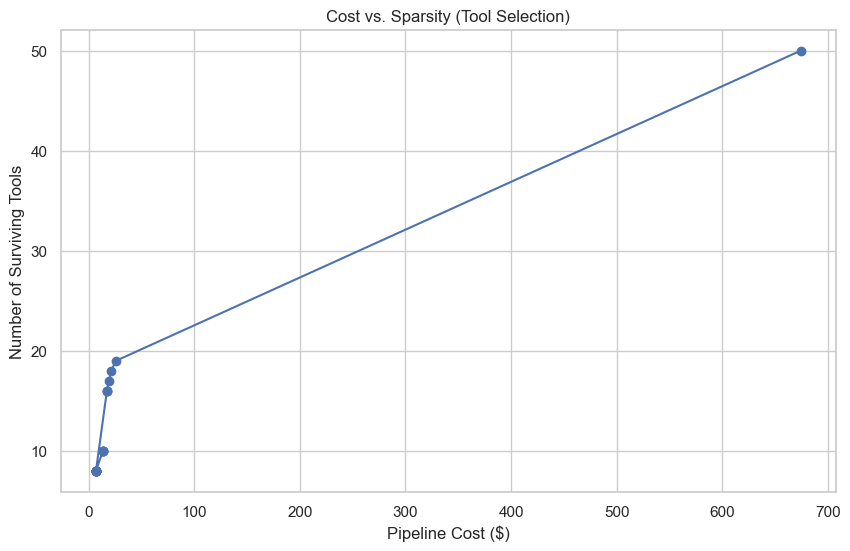

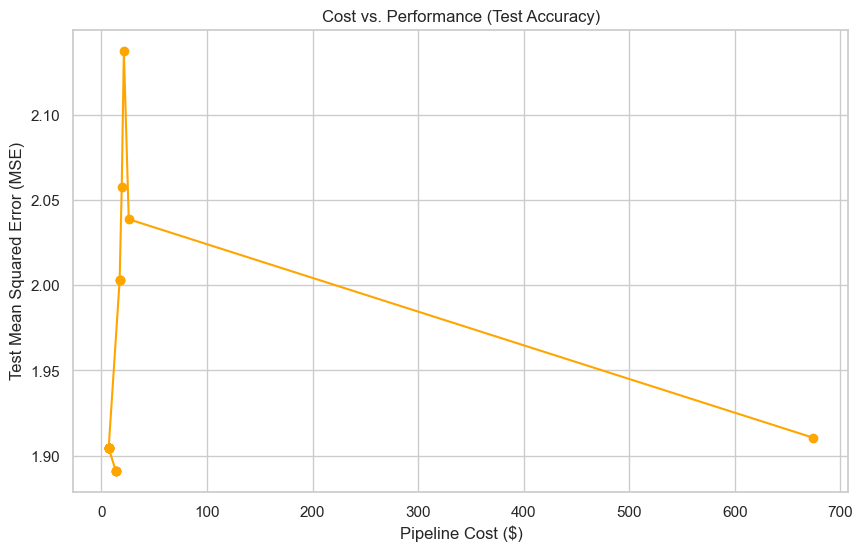

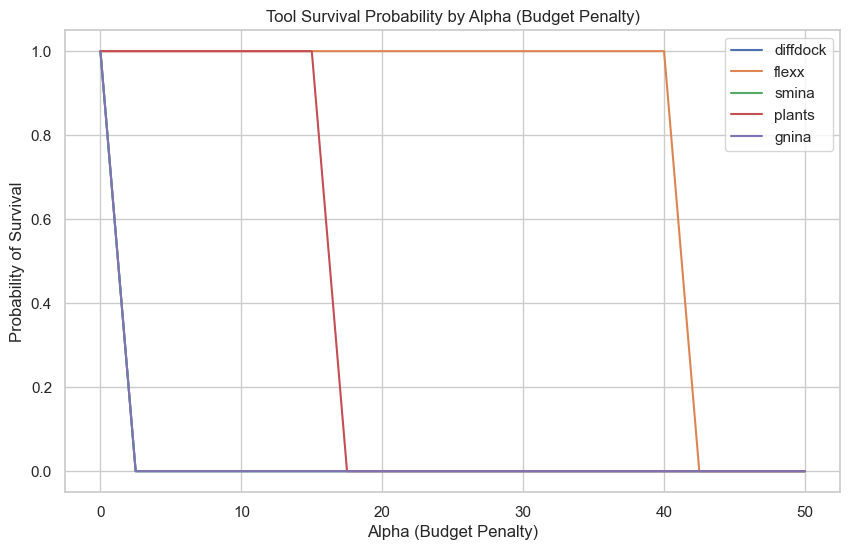

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cost vs. Sparsity (The 'Complexity' curve)
plt.figure(figsize=(10, 6))
# We group by alpha to show how the average number of tools (n_tools) drops as cost shrinks
df_grouped = df_weights.groupby("alpha").agg({"pipeline_cost": "mean", "active_features_count": ["mean", "std"]})
plt.errorbar(df_grouped["pipeline_cost"]["mean"], df_grouped["active_features_count"]["mean"], 
             yerr=df_grouped["active_features_count"]["std"], fmt='-o')
plt.title("Cost vs. Sparsity (Tool Selection)")
plt.xlabel("Pipeline Cost ($)")
plt.ylabel("Number of Surviving Tools")
plt.grid(True)
plt.show()

# 2. Cost vs. Performance (The 'Pareto Tradeoff' curve)
plt.figure(figsize=(10, 6))
df_perf = df_weights.groupby("alpha").agg({"pipeline_cost": "mean", "mse_test": ["mean", "std"]})
plt.errorbar(df_perf["pipeline_cost"]["mean"], df_perf["mse_test"]["mean"], 
             yerr=df_perf["mse_test"]["std"], fmt='-o', color='orange')
plt.title("Cost vs. Performance (Test Accuracy)")
plt.xlabel("Pipeline Cost ($)")
plt.ylabel("Test Mean Squared Error (MSE)")
plt.grid(True)
plt.show()

# 3. The Survival Plot (The 'Death of the Tools')
# This plots the probability (0 to 1) of each tool surviving at different cost levels
survival_cols = [f"sel_{t}" for t in all_docking_tools]
df_survival = df_weights.groupby("alpha")[survival_cols].mean()

plt.figure(figsize=(10, 6))
for tool in survival_cols:
    plt.plot(df_survival.index, df_survival[tool], label=tool.replace("sel_", ""))
plt.title("Tool Survival Probability by Alpha (Budget Penalty)")
plt.xlabel("Alpha (Budget Penalty)")
plt.ylabel("Probability of Survival")
plt.legend()
plt.grid(True)
plt.show()